
#### Final Paper link: 
https://drive.google.com/file/d/1lg-AjJf-JF9RDX68-bxSRmZ0y5ZgA-8N/view?usp=sharing

#### Dataset: 
Martínez, L., Robles, E., Trofimoff, V., Vidal, N., Espada, A. D., Mosquera, N., Franco, B., &
Sarmiento, V. (2022). Self-reported subjective well-being and mental health of college
students - 2022. Mendeley Data, V1. https://doi.org/10.17632/bytb22nf7m.1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
import warnings
from sklearn.exceptions import ConvergenceWarning
import hyperopt
import time
import xgboost as xgb
from hyperopt import hp, fmin, tpe, Trials, partial, STATUS_OK
from xgboost import XGBRegressor
from hyperopt.early_stop import no_progress_loss
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso

In [2]:
# Suppress specific warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # To ignore convergence warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Download from website and save it as csv
data = pd.read_csv('/kaggle/input/subjective-mental-health-of-college-students/dataset_1.csv')

In [4]:
data.iloc[1:]

,DEMOGRAPHIC DATA,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,SUBJECTIVE WELLBEING,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41
1,2001,1,4,6,25,25,7,5,5,5,...,3,0,0,0,1,3,0,0,0,0
2,1999,1,2,1,NaN,NaN,8,4,8,3,...,1,2,2,0,3,2,1,1,0,0
3,2002,1,5,6,16,16,10,9,10,7,...,1,0,1,0,2,2,1,1,1,0
4,2001,2,5,6,20,16,10,8,10,10,...,0,3,1,0,3,1,0,0,0,0
5,1999,1,4,5,NaN,NaN,8,6,7,3,...,1,2,1,3,1,1,0,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988,1985,2,4,6,11,15,8,5,3,6,...,3,0,1,0,1,1,1,1,2,0
2989,1988,1,5,6,5,7,9,8,8,9,...,0,1,0,1,1,1,0,0,0,0
2990,1978,1,3,5,5,4,7,8,9,8,...,1,1,0,1,1,0,1,0,0,0
2991,1990,1,3,6,11,17,7,8,8,6,...,2,3,3,3,3,1,3,1,3,0


In [5]:
data = data.iloc[1:]

In [6]:
data.columns

Index(['DEMOGRAPHIC DATA', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3',
       'Unnamed: 4', 'Unnamed: 5', 'SUBJECTIVE WELLBEING', 'Unnamed: 7',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'HEALTH', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25',
       'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29',
       'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33',
       'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37',
       'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41'],
      dtype='object')

In [7]:
new_column_names = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5.1','Q5.2', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 
                    'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 
                    'Q16.1', 'Q16.2', 'Q16.3', 'Q16.4', 'Q16.5', 
                    'Q16.6', 'Q16.7', 'Q16.8', 'Q16.9', 'Q16.10', 
                    'Q17.1', 'Q17.2', 'Q17.3', 'Q17.4', 'Q17.5', 
                    'Q17.6', 'Q17.7',
                    'Q18.1', 'Q18.2', 'Q18.3', 'Q18.4', 'Q18.5', 
                    'Q18.6', 'Q18.7', 'Q18.8', 'Q18.9']

# Rename the columns
data.columns = new_column_names

# Check the new column names
print(data.columns)

Index(['Q1', 'Q2', 'Q3', 'Q4', 'Q5.1', 'Q5.2', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10',
       'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16.1', 'Q16.2', 'Q16.3', 'Q16.4',
       'Q16.5', 'Q16.6', 'Q16.7', 'Q16.8', 'Q16.9', 'Q16.10', 'Q17.1', 'Q17.2',
       'Q17.3', 'Q17.4', 'Q17.5', 'Q17.6', 'Q17.7', 'Q18.1', 'Q18.2', 'Q18.3',
       'Q18.4', 'Q18.5', 'Q18.6', 'Q18.7', 'Q18.8', 'Q18.9'],
      dtype='object')


In [8]:
#data for PSS-10
print(data.iloc[:,16:26])

     Q16.1 Q16.2 Q16.3 Q16.4 Q16.5 Q16.6 Q16.7 Q16.8 Q16.9 Q16.10
1        1     2     2     3     3     0     3     3     3      1
2        1     2     3     2     2     2     3     2     3      2
3        2     1     2     3     2     2     3     1     1      2
4        3     3     2     4     4     2     3     3     2      1
5        3     1     2     3     2     3     3     2     2      1
...    ...   ...   ...   ...   ...   ...   ...   ...   ...    ...
2988     2     3     3     2     3     2     3     2     2      2
2989     3     1     2     4     4     1     4     2     2      1
2990     2     1     3     4     3     1     3     2     1      2
2991     1     3     4     2     3     4     3     2     1      3
2992     2     1     3     3     3     1     3     2     1      1

[2992 rows x 10 columns]


In [9]:
#data for GAD-7
print(data.iloc[:,26:33])

     Q17.1 Q17.2 Q17.3 Q17.4 Q17.5 Q17.6 Q17.7
1        1     0     0     0     3     0     3
2        0     3     1     1     0     1     1
3        1     2     1     2     1     0     1
4        0     0     1     0     0     1     0
5        1     0     0     0     0     0     1
...    ...   ...   ...   ...   ...   ...   ...
2988     3     3     1     3     2     3     3
2989     1     0     1     1     1     1     0
2990     2     0     1     1     2     0     1
2991     3     1     3     2     3     0     2
2992     1     0     0     0     0     0     0

[2992 rows x 7 columns]


In [10]:
# data for PHQ-9
print(data.iloc[:,33:])

     Q18.1 Q18.2 Q18.3 Q18.4 Q18.5 Q18.6 Q18.7 Q18.8 Q18.9
1        0     0     0     1     3     0     0     0     0
2        2     2     0     3     2     1     1     0     0
3        0     1     0     2     2     1     1     1     0
4        3     1     0     3     1     0     0     0     0
5        2     1     3     1     1     0     1     0     3
...    ...   ...   ...   ...   ...   ...   ...   ...   ...
2988     0     1     0     1     1     1     1     2     0
2989     1     0     1     1     1     0     0     0     0
2990     1     0     1     1     0     1     0     0     0
2991     3     3     3     3     1     3     1     3     0
2992     0     0     0     0     0     0     0     0     0

[2992 rows x 9 columns]


In [11]:
for col in ['Q16.1', 'Q16.2', 'Q16.3', 'Q16.4', 'Q16.5', 'Q16.6', 
            'Q16.7', 'Q16.8', 'Q16.9', 'Q16.10']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Reverse scores for questions 4, 5, 7, and 8
data['Q16.4'] = 4 - data['Q16.4']
data['Q16.5'] = 4 - data['Q16.5']
data['Q16.7'] = 4 - data['Q16.7']
data['Q16.8'] = 4 - data['Q16.8']

# Calculate total score
data['PSS_total'] = data[['Q16.1', 'Q16.2', 'Q16.3', 'Q16.4', 'Q16.5', 
                           'Q16.6', 'Q16.7', 'Q16.8', 'Q16.9', 'Q16.10']].sum(axis=1)

# Create PSS_result category based on total score
def categorize_pss(score):
    if score <= 13:
        return 'Low'
    elif score <= 26:
        return 'Moderate'
    else:
        return 'High'

data['PSS_result'] = data['PSS_total'].apply(categorize_pss)

# Display the updated DataFrame with the new column
print(data[['PSS_total', 'PSS_result']].head())

   PSS_total PSS_result
1         13        Low
2         20   Moderate
3         17   Moderate
4         15   Moderate
5         18   Moderate


In [12]:
for col in ['Q17.1', 'Q17.2', 'Q17.3', 'Q17.4', 'Q17.5', 'Q17.6', 'Q17.7']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Calculate total GAD-7 score
data['GAD_total'] = data[['Q17.1', 'Q17.2', 'Q17.3', 'Q17.4', 'Q17.5', 'Q17.6', 'Q17.7']].sum(axis=1)

# Create GAD_result category based on total score
def categorize_gad(score):
    if score <= 4:
        return 'minimal anxiety'
    elif score <= 9:
        return 'mild anxiety'
    elif score <= 14:
        return 'moderate anxiety'
    elif score <= 21:
        return 'severe anxiety'
    else:
        return 'invalid score'  # In case scores exceed expected range

data['GAD_result'] = data['GAD_total'].apply(categorize_gad)

# Display the updated DataFrame with the new columns
print(data[['GAD_total', 'GAD_result']].head())

   GAD_total       GAD_result
1          7     mild anxiety
2          7     mild anxiety
3          8     mild anxiety
4          2  minimal anxiety
5          2  minimal anxiety


In [13]:
for col in ['Q18.1', 'Q18.2', 'Q18.3', 'Q18.4', 'Q18.5', 'Q18.6', 'Q18.7', 'Q18.8', 'Q18.9']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Calculate total PHQ-9 score
data['PHQ_total'] = data[['Q18.1', 'Q18.2', 'Q18.3', 'Q18.4', 'Q18.5', 'Q18.6', 'Q18.7', 'Q18.8', 'Q18.9']].sum(axis=1)

# Create PHQ_result category based on total score
def categorize_phq(score):
    if score >= 1 and score <= 4:
        return 'Minimal depression'
    elif score <= 9:
        return 'Mild depression'
    elif score <= 14:
        return 'Moderate depression'
    elif score <= 19:
        return 'Moderately severe depression'
    elif score <= 27:
        return 'Severe depression'
    else:
        return 'Invalid score'  # In case scores exceed expected range

data['PHQ_result'] = data['PHQ_total'].apply(categorize_phq)

print(data[['PHQ_total', 'PHQ_result']].head())

   PHQ_total           PHQ_result
1          4   Minimal depression
2         11  Moderate depression
3          8      Mild depression
4          8      Mild depression
5         12  Moderate depression


In [14]:
# Since the data is collected in 2022, we want to calculate the age of interviewer in that years
data['Q1'] = data['Q1'].astype(int)
data['Q1'] = 2022 - data['Q1']

In [15]:
data

,Q1,Q2,Q3,Q4,Q5.1,Q5.2,Q6,Q7,Q8,Q9,...,Q18.6,Q18.7,Q18.8,Q18.9,PSS_total,PSS_result,GAD_total,GAD_result,PHQ_total,PHQ_result
1,21,1,4,6,25,25,7,5,5,5,...,0,0,0,0,13,Low,7,mild anxiety,4,Minimal depression
2,23,1,2,1,NaN,NaN,8,4,8,3,...,1,1,0,0,20,Moderate,7,mild anxiety,11,Moderate depression
3,20,1,5,6,16,16,10,9,10,7,...,1,1,1,0,17,Moderate,8,mild anxiety,8,Mild depression
4,21,2,5,6,20,16,10,8,10,10,...,0,0,0,0,15,Moderate,2,minimal anxiety,8,Mild depression
5,23,1,4,5,NaN,NaN,8,6,7,3,...,0,1,0,3,18,Moderate,2,minimal anxiety,12,Moderate depression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988,37,2,4,6,11,15,8,5,3,6,...,1,1,2,0,20,Moderate,18,severe anxiety,7,Mild depression
2989,34,1,5,6,5,7,9,8,8,9,...,0,0,0,0,12,Low,5,mild anxiety,4,Minimal depression
2990,44,1,3,5,5,4,7,8,9,8,...,1,0,0,0,14,Moderate,7,mild anxiety,4,Minimal depression
2991,32,1,3,6,11,17,7,8,8,6,...,3,1,3,0,22,Moderate,14,moderate anxiety,20,Severe depression


In [16]:
data.to_csv('cleaned_dataset_1.csv', index=False)

In [17]:
data = pd.read_csv('/kaggle/working/cleaned_dataset_1.csv')

In [18]:
data.head()

,Q1,Q2,Q3,Q4,Q5.1,Q5.2,Q6,Q7,Q8,Q9,...,Q18.6,Q18.7,Q18.8,Q18.9,PSS_total,PSS_result,GAD_total,GAD_result,PHQ_total,PHQ_result
0,21,1,4,6,25.0,25.0,7,5,5,5,...,0,0,0,0,13,Low,7,mild anxiety,4,Minimal depression
1,23,1,2,1,NaN,NaN,8,4,8,3,...,1,1,0,0,20,Moderate,7,mild anxiety,11,Moderate depression
2,20,1,5,6,16.0,16.0,10,9,10,7,...,1,1,1,0,17,Moderate,8,mild anxiety,8,Mild depression
3,21,2,5,6,20.0,16.0,10,8,10,10,...,0,0,0,0,15,Moderate,2,minimal anxiety,8,Mild depression
4,23,1,4,5,NaN,NaN,8,6,7,3,...,0,1,0,3,18,Moderate,2,minimal anxiety,12,Moderate depression


In [19]:
null_counts = data.isnull().sum()

# Create a DataFrame to display null counts
null_counts_df = pd.DataFrame(null_counts, columns=['Null Count'])
null_counts_df['Percentage'] = (null_counts_df['Null Count'] / len(data)) * 100  # Calculate percentage of nulls

# Print the null counts as a table
print("Number of null values in each column:")
print(null_counts_df)

Number of null values in each column:
            Null Count  Percentage
Q1                   0    0.000000
Q2                   0    0.000000
Q3                   0    0.000000
Q4                   0    0.000000
Q5.1               954   31.885027
Q5.2              1059   35.394385
Q6                   0    0.000000
Q7                   0    0.000000
Q8                   0    0.000000
Q9                   0    0.000000
Q10                  0    0.000000
Q11                  0    0.000000
Q12                  0    0.000000
Q13                  0    0.000000
Q14                  0    0.000000
Q15                  0    0.000000
Q16.1                0    0.000000
Q16.2                0    0.000000
Q16.3                0    0.000000
Q16.4                0    0.000000
Q16.5                0    0.000000
Q16.6                0    0.000000
Q16.7                0    0.000000
Q16.8                0    0.000000
Q16.9                0    0.000000
Q16.10               0    0.000000
Q17.1            

How many years of education did your parents receive? 5.1 for Father, 5.2 for Mother

It's seems to be most of the people no willing to answer this question, maybe some people is sensitive to this question, If we want to design a survey for investigating depression, we should avoid similar question that related to the parents information.

In [20]:
data = data.drop(data.columns[4:6], axis=1)

In [21]:
data.iloc[:,0:31]

,Q1,Q2,Q3,Q4,Q6,Q7,Q8,Q9,Q10,Q11,...,Q16.8,Q16.9,Q16.10,Q17.1,Q17.2,Q17.3,Q17.4,Q17.5,Q17.6,Q17.7
0,21,1,4,6,7,5,5,5,7,8,...,1,3,1,1,0,0,0,3,0,3
1,23,1,2,1,8,4,8,3,5,8,...,2,3,2,0,3,1,1,0,1,1
2,20,1,5,6,10,9,10,7,10,0,...,3,1,2,1,2,1,2,1,0,1
3,21,2,5,6,10,8,10,10,10,2,...,1,2,1,0,0,1,0,0,1,0
4,23,1,4,5,8,6,7,3,9,0,...,2,2,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2987,37,2,4,6,8,5,3,6,8,9,...,2,2,2,3,3,1,3,2,3,3
2988,34,1,5,6,9,8,8,9,8,9,...,2,2,1,1,0,1,1,1,1,0
2989,44,1,3,5,7,8,9,8,9,9,...,2,1,2,2,0,1,1,2,0,1
2990,32,1,3,6,7,8,8,6,8,10,...,2,1,3,3,1,3,2,3,0,2


Demographic Feature

In [22]:
data.iloc[:,0:4]

,Q1,Q2,Q3,Q4
0,21,1,4,6
1,23,1,2,1
2,20,1,5,6
3,21,2,5,6
4,23,1,4,5
...,...,...,...,...
2987,37,2,4,6
2988,34,1,5,6
2989,44,1,3,5
2990,32,1,3,6


Subjective well-being Feature

In [23]:
data.iloc[:,4:14]

,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15
0,7,5,5,5,7,8,0,0,0,0
1,8,4,8,3,5,8,3,2,8,7
2,10,9,10,7,10,0,1,1,1,0
3,10,8,10,10,10,2,0,0,4,0
4,8,6,7,3,9,0,2,0,7,10
...,...,...,...,...,...,...,...,...,...,...
2987,8,5,3,6,8,9,8,1,3,0
2988,9,8,8,9,8,9,1,1,6,1
2989,7,8,9,8,9,9,6,5,8,5
2990,7,8,8,6,8,10,10,2,10,3


Response of PSS-10

In [24]:
data.iloc[:,14:24]

,Q16.1,Q16.2,Q16.3,Q16.4,Q16.5,Q16.6,Q16.7,Q16.8,Q16.9,Q16.10
0,1,2,2,1,1,0,1,1,3,1
1,1,2,3,2,2,2,1,2,3,2
2,2,1,2,1,2,2,1,3,1,2
3,3,3,2,0,0,2,1,1,2,1
4,3,1,2,1,2,3,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...
2987,2,3,3,2,1,2,1,2,2,2
2988,3,1,2,0,0,1,0,2,2,1
2989,2,1,3,0,1,1,1,2,1,2
2990,1,3,4,2,1,4,1,2,1,3


Response of GAD-7

In [25]:
data.iloc[:,24:31]

,Q17.1,Q17.2,Q17.3,Q17.4,Q17.5,Q17.6,Q17.7
0,1,0,0,0,3,0,3
1,0,3,1,1,0,1,1
2,1,2,1,2,1,0,1
3,0,0,1,0,0,1,0
4,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...
2987,3,3,1,3,2,3,3
2988,1,0,1,1,1,1,0
2989,2,0,1,1,2,0,1
2990,3,1,3,2,3,0,2


This column is the target

In [26]:
data.iloc[:,44]

0        4
1       11
2        8
3        8
4       12
        ..
2987     7
2988     4
2989     4
2990    20
2991     0
Name: PHQ_total, Length: 2992, dtype: int64

In [27]:
X = data.iloc[:,0:31]
y = data.iloc[:,44]
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,0:31], data.iloc[:,44], test_size=0.2, random_state=1412)
X_train1, X_test1, y_train1, y_test1 = train_test_split(data.iloc[:,0:31], data.iloc[:,45], test_size=0.2, random_state=1412)
data_xgb = xgb.DMatrix(X_train,label=y_train,enable_categorical = True)

In [28]:
param_grid_simple = {
    "eta": hp.choice("eta", [0.01, 0.1, 0.2]),  # Fixed learning rates
    "colsample_bytree": hp.uniform("colsample_bytree", 0.7, 0.9),  # Narrowed range
    "lambda": hp.quniform("lambda", 0, 3, 0.2),  # Keep the original range
    "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),  # Smaller range
    "max_depth": hp.choice("max_depth", [3, 5, 7]),  # Discrete values
    "subsample": hp.uniform("subsample", 0.7, 0.9)
}

def hyperopt_objective(params):
    paramsforxgb = {
        "eta": params["eta"],
        "colsample_bytree": params["colsample_bytree"],
        "lambda": params["lambda"],
        "min_child_weight": int(params["min_child_weight"]),  # Ensure it's an integer
        "max_depth": int(params["max_depth"]),
        "subsample": params["subsample"],
        "nthread": 14,
        "verbosity": 0,
        "seed": 1412
    }

    result = xgb.cv(paramsforxgb, data_xgb, seed=1412, metrics=("rmse"),
                    num_boost_round=1000)
    return result.iloc[-1, 2]

def param_hyperopt(max_evals=100):
    trials = Trials()

    early_stop_fn = no_progress_loss(30)

    params_best = fmin(hyperopt_objective,
                       space=param_grid_simple,
                       algo=tpe.suggest,
                       max_evals=max_evals,
                       verbose=True,
                       trials=trials,
                       early_stop_fn=early_stop_fn)

    print("\n", "\n", "best params: ", params_best, "\n")
    return params_best, trials

# Measure the running time
start = time.time()
params_best, trials = param_hyperopt(100)
end = time.time()
print(end - start)

 52%|█████▏    | 52/100 [02:06<01:57,  2.44s/trial, best loss: 3.7966717237670164]

 
 best params:  {'colsample_bytree': 0.738034311269394, 'eta': 0, 'lambda': 2.2, 'max_depth': 1, 'min_child_weight': 6.0, 'subsample': 0.7094005477525268} 

126.97895240783691


In [29]:
xgb_params = {
    'colsample_bytree': 0.7260500485561359,
    'eta': 0.01,
    'lambda': 2.6,
    'max_depth': 3,
    'min_child_weight': 7,
    'subsample': 0.7004655412810042,
    'objective': 'reg:squarederror',  # Objective for regression
    'n_estimators': 1000  # Number of boosting rounds
}

# Create the XGBoost model
model_xgb = XGBRegressor(**xgb_params)

# Train the model
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7260500485561359, device=None,
             early_stopping_rounds=None, enable_categorical=False, eta=0.01,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, lambda=2.6, learning_rate=None,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=7, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, ...)

In [30]:
y_pred_xgb = model_xgb.predict(X_test)
# Evaluate the model
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
print(f'Mean Squared Error for Xgboost: {xgb_mse}')

Mean Squared Error for Xgboost: 12.55923080444336


Top 5 Feature Importances(XGBoost):
   Feature  Importance
26   Q17.3    0.235293
27   Q17.4    0.130179
24   Q17.1    0.090878
23  Q16.10    0.087185
15   Q16.2    0.052413


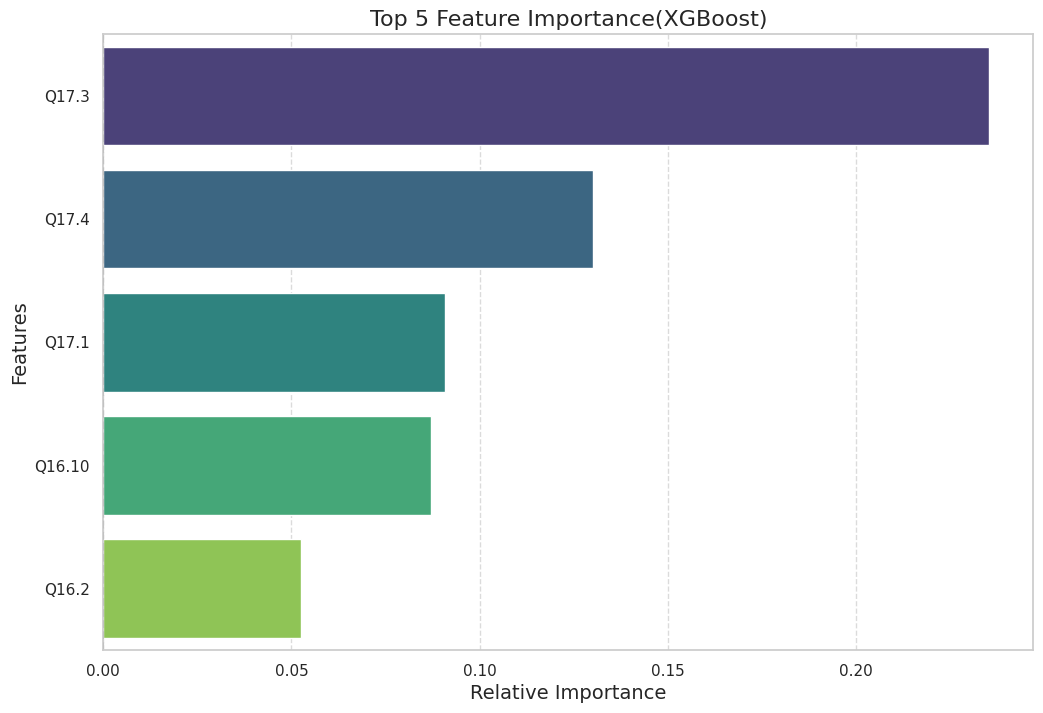

In [31]:
importance_xgb = model_xgb.feature_importances_

# Create a DataFrame for better visualization
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame
    'Importance': importance_xgb
})

# Sort the DataFrame by importance
feature_importance_xgb = feature_importance_xgb.sort_values(by='Importance', ascending=False)

# Print top 10 feature importances
print("Top 5 Feature Importances(XGBoost):")
print(feature_importance_xgb.head(5))

# Set the style of seaborn
sns.set(style="whitegrid")
# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb.head(5), palette='viridis')
plt.title('Top 5 Feature Importance(XGBoost)', fontsize=16)
plt.xlabel('Relative Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('top_5_feature_importance_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
def objective(params):
    alpha = params['alpha']

    # Create the Lasso model
    model = Lasso(alpha=alpha)

    # Perform cross-validation and calculate the mean squared error
    mse_scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)

    # Return the mean of the negative MSE (since cross_val_score returns negative values)
    return {'loss': -mse_scores.mean(), 'status': STATUS_OK}

# Define the search space
space = {
    'alpha': hp.loguniform('alpha', -4, 1)  # Search space for alpha in the range (0.018, 20.085)
}

# Run Hyperopt
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)

# Print the best hyperparameters
print("Best hyperparameters:", best)

# Train the final model with the best hyperparameters
model_lasso = Lasso(alpha=best['alpha'])
model_lasso.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred_lasso = model_lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
print(f"Mean Squared Error for Lasso Regression: {lasso_mse}")

100%|██████████| 100/100 [00:02<00:00, 33.96trial/s, best loss: 13.686950557953661]
Best hyperparameters: {'alpha': 0.06787520269651647}
Mean Squared Error for Lasso Regression: 12.557445089536083


Top 5 Feature Importances(Lasso Regression):
   Feature  Coefficient  Absolute Coefficient
28   Q17.5     0.959533              0.959533
29   Q17.6     0.713487              0.713487
27   Q17.4     0.630055              0.630055
30   Q17.7     0.551376              0.551376
19   Q16.6     0.547438              0.547438


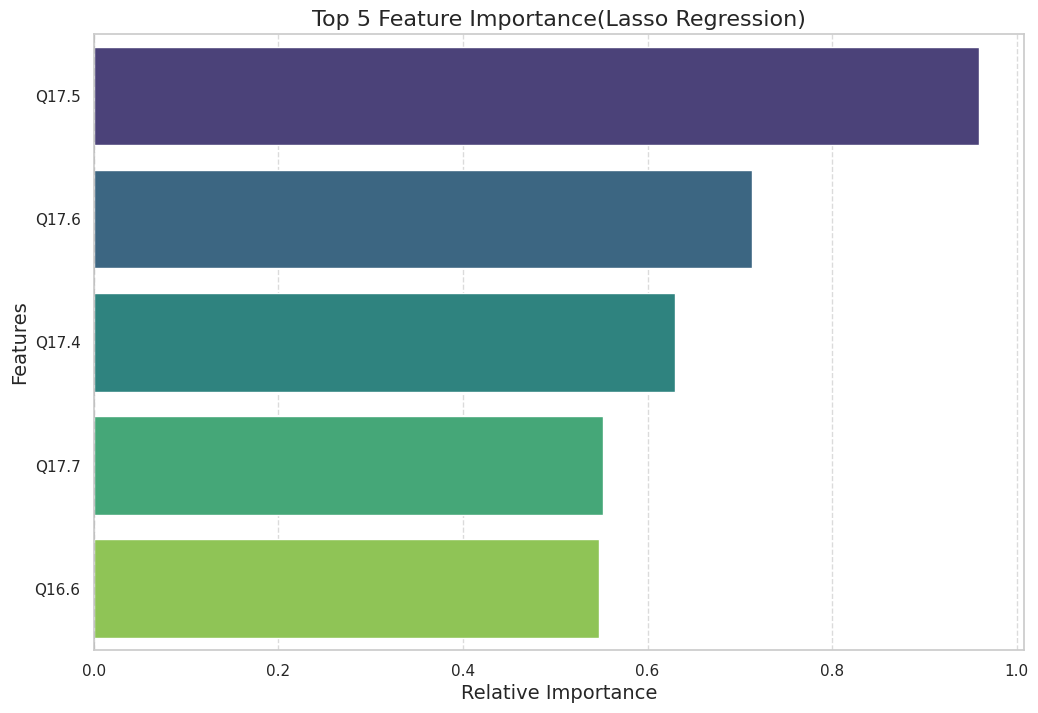

In [33]:
importance_lasso = model_lasso.coef_

# Create a DataFrame for better visualization
feature_importance_lasso = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame
    'Coefficient': importance_lasso
})

# Sort the DataFrame by importance
feature_importance_lasso['Absolute Coefficient'] = feature_importance_lasso['Coefficient'].abs()
feature_importance_lasso = feature_importance_lasso.sort_values(by='Absolute Coefficient', ascending=False)

# Print top 10 feature importances
print("Top 5 Feature Importances(Lasso Regression):")
print(feature_importance_lasso.head(5))

# Set the style of seaborn
sns.set(style="whitegrid")
# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_lasso.head(5), palette='viridis')
plt.title('Top 5 Feature Importance(Lasso Regression)', fontsize=16)
plt.xlabel('Relative Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('top_5_feature_importance_lasso.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
param_grid_rf = {
    "n_estimators": hp.choice("n_estimators", [50, 100, 200]),  # Number of trees
    "max_depth": hp.choice("max_depth", [None, 5, 10, 15]),  # Maximum depth of the tree
    "min_samples_split": hp.quniform("min_samples_split", 2, 10, 1),  # Minimum samples to split
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 4, 1),  # Minimum samples at leaf node
    "max_features": hp.choice("max_features", ["sqrt", "log2"]),  # Number of features to consider
}

# Define the objective function for Hyperopt
def hyperopt_objective(params):
    # Ensure integer values for certain parameters
    params["min_samples_split"] = int(params["min_samples_split"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])

    # Create and train the Random Forest model
    model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        random_state=1412,
        n_jobs=-1  # Use all available cores
    )

    # Perform cross-validation and calculate the mean RMSE
    cv_scores = cross_val_score(model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5)

    # Return the mean of the negative RMSE (since cross_val_score returns negative values)
    return -cv_scores.mean()  # Return the mean RMSE as the loss to minimize

# Hyperparameter optimization function
def param_hyperopt(max_evals=100):
    trials = Trials()

    params_best = fmin(
        hyperopt_objective,
        space=param_grid_rf,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        verbose=True
    )

    print("\n", "\n", "Best params: ", params_best, "\n")
    return params_best, trials

# Measure the running time
start = time.time()
params_best, trials = param_hyperopt(100)
end = time.time()
print("Time taken for optimization:", end - start)


100%|██████████| 100/100 [02:38<00:00,  1.59s/trial, best loss: 3.7523337291121215]

 
 Best params:  {'max_depth': 3, 'max_features': 0, 'min_samples_leaf': 2.0, 'min_samples_split': 4.0, 'n_estimators': 2} 

Time taken for optimization: 158.99757313728333


In [35]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=1412,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

# Evaluate the final model on the test set
y_pred_rf = model_rf.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred_rf)
print(f"Mean Squared Error for Random Forest: {rf_mse}")

Mean Squared Error for Random Forest: 12.867436900828602


Top 5 Feature Importances(Random Forest):
   Feature  Importance
27   Q17.4    0.090004
26   Q17.3    0.081150
10     Q12    0.068466
23  Q16.10    0.063670
28   Q17.5    0.059219


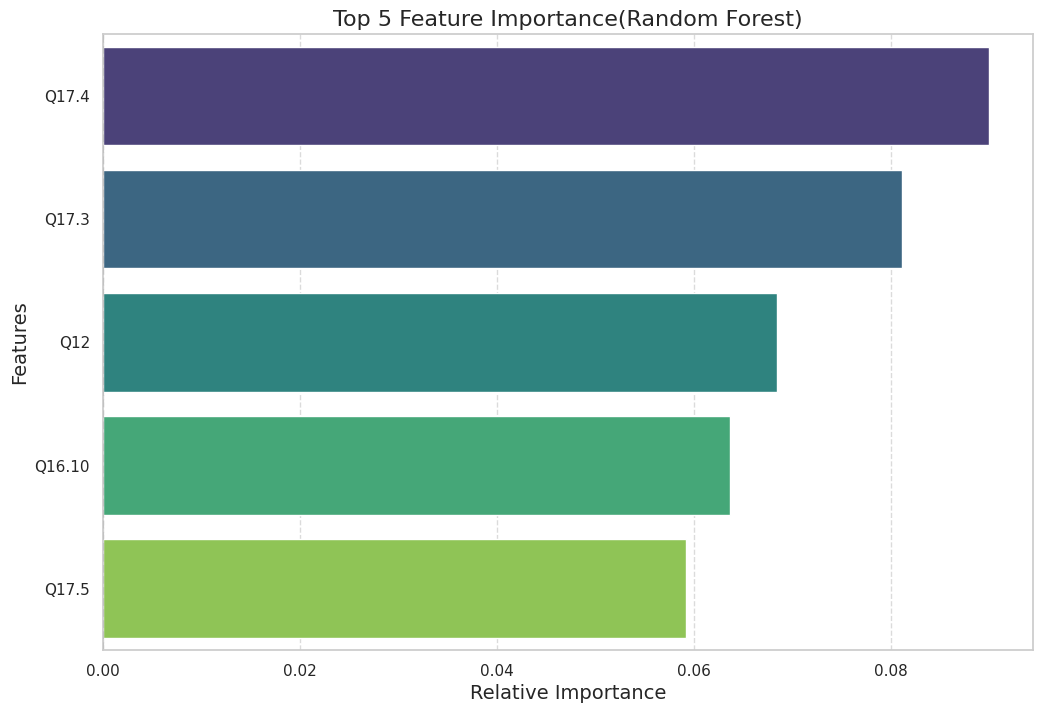

In [36]:
importance_rf = model_rf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame
    'Importance': importance_rf
})

# Sort the DataFrame by importance
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Print top 10 feature importances
print("Top 5 Feature Importances(Random Forest):")
print(feature_importance_rf.head(5))

# Set the style of seaborn
sns.set(style="whitegrid")
# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf.head(5), palette='viridis')
plt.title('Top 5 Feature Importance(Random Forest)', fontsize=16)
plt.xlabel('Relative Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('top_5_feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
importance_xgb = model_xgb.feature_importances_

# Create a DataFrame for better visualization
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame
    'Importance': importance_xgb
})

# Sort the DataFrame by importance
feature_importance_xgb = feature_importance_xgb.sort_values(by='Importance', ascending=False)

# Print top 10 feature importances
print("Top 5 Feature Importances(XGBoost):")
print(feature_importance_xgb.head(5))


Top 5 Feature Importances(XGBoost):
   Feature  Importance
26   Q17.3    0.235293
27   Q17.4    0.130179
24   Q17.1    0.090878
23  Q16.10    0.087185
15   Q16.2    0.052413


In [38]:
importance_lasso = model_lasso.coef_

# Create a DataFrame for better visualization
feature_importance_lasso = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame
    'Coefficient': importance_lasso
})

# Sort the DataFrame by importance
feature_importance_lasso['Absolute Coefficient'] = feature_importance_lasso['Coefficient'].abs()
feature_importance_lasso = feature_importance_lasso.sort_values(by='Absolute Coefficient', ascending=False)

# Print top 10 feature importances
print("Top 5 Feature Importances(Lasso Regression):")
print(feature_importance_lasso.head(5))

Top 5 Feature Importances(Lasso Regression):
   Feature  Coefficient  Absolute Coefficient
28   Q17.5     0.959533              0.959533
29   Q17.6     0.713487              0.713487
27   Q17.4     0.630055              0.630055
30   Q17.7     0.551376              0.551376
19   Q16.6     0.547438              0.547438


In [39]:
importance_rf = model_rf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,  # Assuming X_train is a DataFrame
    'Importance': importance_rf
})

# Sort the DataFrame by importance
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Print top 10 feature importances
print("Top 5 Feature Importances(Random Forest):")
print(feature_importance_rf.head(5))

Top 5 Feature Importances(Random Forest):
   Feature  Importance
27   Q17.4    0.090004
26   Q17.3    0.081150
10     Q12    0.068466
23  Q16.10    0.063670
28   Q17.5    0.059219


In [40]:
combined_importance = pd.DataFrame(columns=['Feature', 'Combined Importance'])

combined_importance['Combined Importance'] = (feature_importance_xgb['Importance'] +
                                              feature_importance_lasso['Absolute Coefficient'] +
                                              feature_importance_rf ['Importance'])
combined_importance['Feature'] = feature_importance_rf['Feature']
# Sort the combined importance in descending order
combined_importance = combined_importance.sort_values(by='Combined Importance', ascending=False)

# Print the combined feature importances
print("Combined Feature Importances (Descending Order):")
print(combined_importance[['Feature', 'Combined Importance']].head(5))  # Display top 10 features

Combined Feature Importances (Descending Order):
   Feature  Combined Importance
28   Q17.5             1.059559
27   Q17.4             0.850238
29   Q17.6             0.769218
26   Q17.3             0.748449
30   Q17.7             0.640819


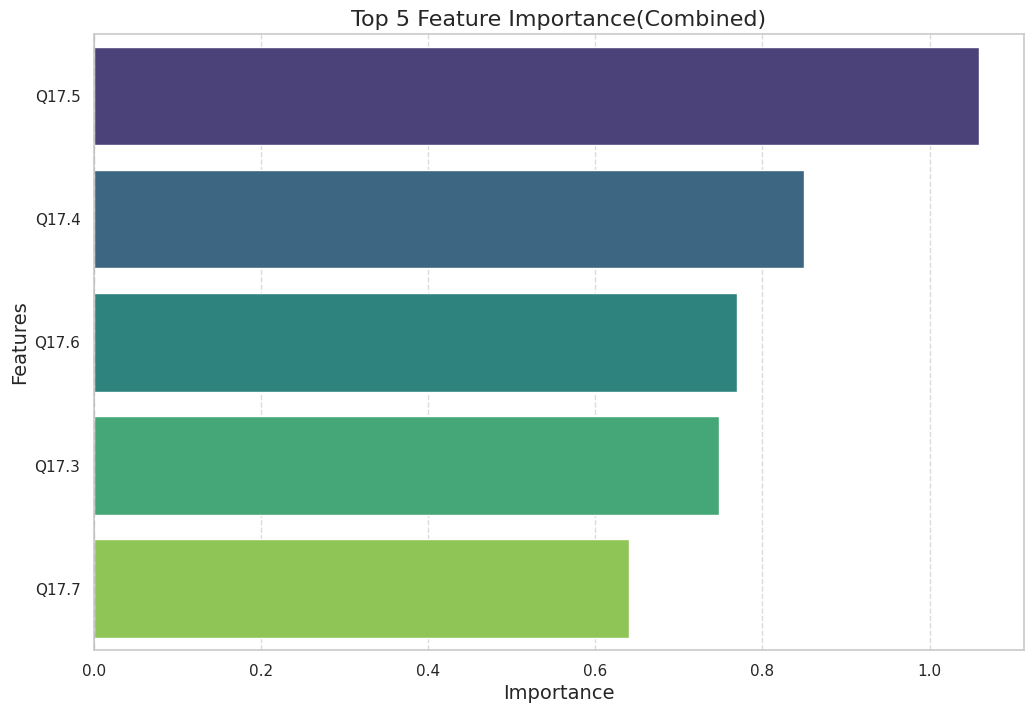

In [41]:
# Set the style of seaborn
sns.set(style="whitegrid")
# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Combined Importance', y='Feature', data=combined_importance.head(5), palette='viridis')
plt.title('Top 5 Feature Importance(Combined)', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('top_5_feature_importance_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
print(f'Mean Squared Error for Xgboost: {xgb_mse}')
print(f'Mean Squared Error for Lasso Regression: {lasso_mse}')
print(f'Mean Squared Error for Random Forest: {rf_mse}')

Mean Squared Error for Xgboost: 12.55923080444336
Mean Squared Error for Lasso Regression: 12.557445089536083
Mean Squared Error for Random Forest: 12.867436900828602


Correlation Matrix:
           GAD_total  PSS_total  PHQ_total
GAD_total   1.000000   0.695061   0.739797
PSS_total   0.695061   1.000000   0.683973
PHQ_total   0.739797   0.683973   1.000000


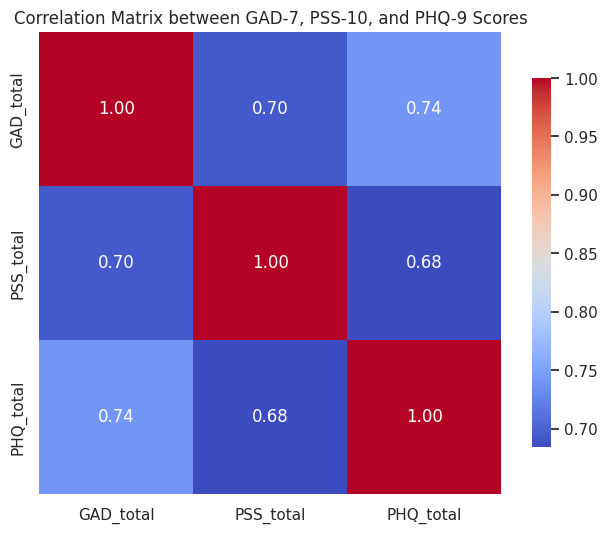

In [43]:
import seaborn as sns
columns = ['GAD_total', 'PSS_total', 'PHQ_total']

# Calculate the correlation matrix
correlation_matrix = data[columns].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix between GAD-7, PSS-10, and PHQ-9 Scores')
plt.show()